<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/updatedandtrainedonORIGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install dependencies and check GPU
!pip install -q albumentations opencv-python-headless timm

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

import os, cv2, glob, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


CUDA available: True
Device: Tesla T4


In [2]:
# Cell 2: Kaggle API authentication
from google.colab import files
print("Upload your kaggle.json file now:")
uploaded = files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle


Upload your kaggle.json file now:


Saving kaggle.json to kaggle.json
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
# Cell 3: Download Glaucoma multi-dataset (ORIGA + REFUGE + G1020) by arnavjain1
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/data --unzip


Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [00:52<00:00, 113MB/s]



In [4]:
# Cell 4: Explore the downloaded folder structure
for root, dirs, fnames in os.walk("/content/data"):
    if fnames and root.count(os.sep) <= "/content/data".count(os.sep) + 4:
        print(root, "->", len(fnames), "files | example:", fnames[0])


/content/data/REFUGE/val -> 1 files | example: index.json
/content/data/REFUGE/val/Masks_Cropped -> 400 files | example: V0181.png
/content/data/REFUGE/val/Images_Cropped -> 400 files | example: V0165.jpg
/content/data/REFUGE/val/Images -> 400 files | example: V0165.jpg
/content/data/REFUGE/val/Masks -> 400 files | example: V0181.png
/content/data/REFUGE/val/gts -> 400 files | example: V0316.bmp
/content/data/REFUGE/test -> 1 files | example: index.json
/content/data/REFUGE/test/Masks_Cropped -> 400 files | example: T0025.png
/content/data/REFUGE/test/Images_Cropped -> 400 files | example: T0390.jpg
/content/data/REFUGE/test/Images -> 400 files | example: T0390.jpg
/content/data/REFUGE/test/Masks -> 400 files | example: T0025.png
/content/data/REFUGE/test/gts -> 400 files | example: T0021.bmp
/content/data/REFUGE/Masks_Square -> 1200 files | example: n0322.png
/content/data/REFUGE/Images_Square -> 1200 files | example: T0390.jpg
/content/data/REFUGE/train -> 1 files | example: index.js

In [5]:
# Cell 5: Explore and confirm ORIGA folder layout
# Same Kaggle aggregator (arnavjain1/glaucoma-datasets) processed ORIGA the same way as
# G1020/REFUGE -- Images_Cropped/Masks_Cropped convention -- but confirm the exact path
# before trusting it, since the inner folder name could differ slightly.

import subprocess
result = subprocess.run(["find", "/content/data", "-iname", "*origa*", "-maxdepth", "3"],
                         capture_output=True, text=True)
print("Folders matching 'origa':")
print(result.stdout)

ORIGA_IMG_DIR = "/content/data/ORIGA/Images_Cropped/img"
ORIGA_MASK_DIR = "/content/data/ORIGA/Masks_Cropped/img"

print("\nImages found:", os.path.exists(ORIGA_IMG_DIR), "->", len(os.listdir(ORIGA_IMG_DIR)) if os.path.exists(ORIGA_IMG_DIR) else "PATH MISSING, adjust ORIGA_IMG_DIR above")
print("Masks found:", os.path.exists(ORIGA_MASK_DIR), "->", len(os.listdir(ORIGA_MASK_DIR)) if os.path.exists(ORIGA_MASK_DIR) else "PATH MISSING, adjust ORIGA_MASK_DIR above")

if os.path.exists(ORIGA_IMG_DIR):
    print("\nSample image files:", sorted(os.listdir(ORIGA_IMG_DIR))[:5])
if os.path.exists(ORIGA_MASK_DIR):
    print("Sample mask files:", sorted(os.listdir(ORIGA_MASK_DIR))[:5])

Folders matching 'origa':
/content/data/ORIGA
/content/data/ORIGA/origa_info.csv
/content/data/ORIGA/OrigaList.csv


Images found: False -> PATH MISSING, adjust ORIGA_IMG_DIR above
Masks found: False -> PATH MISSING, adjust ORIGA_MASK_DIR above


In [7]:
# Cell 5b: Deeper exploration of ORIGA structure
import os

print("=== Full directory tree under /content/data/ORIGA ===")
for root, dirs, fnames in os.walk("/content/data/ORIGA"):
    depth = root.replace("/content/data/ORIGA", "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}{root}/  ({len(fnames)} files)")
    if fnames:
        print(f"{indent}  examples: {fnames[:5]}")

print("\n=== origa_info.csv (first 5 rows) ===")
import pandas as pd
info_df = pd.read_csv("/content/data/ORIGA/origa_info.csv")
print(info_df.shape)
print(info_df.head())
print("Columns:", list(info_df.columns))

print("\n=== OrigaList.csv (first 5 rows) ===")
list_df = pd.read_csv("/content/data/ORIGA/OrigaList.csv")
print(list_df.shape)
print(list_df.head())
print("Columns:", list(list_df.columns))

=== Full directory tree under /content/data/ORIGA ===
/content/data/ORIGA/  (2 files)
  examples: ['origa_info.csv', 'OrigaList.csv']
  /content/data/ORIGA/Masks_Cropped/  (650 files)
    examples: ['181.png', '624.png', '522.png', '027.png', '455.png']
  /content/data/ORIGA/Images_Cropped/  (650 files)
    examples: ['559.jpg', '492.jpg', '521.jpg', '644.jpg', '294.jpg']
  /content/data/ORIGA/Masks_Square/  (651 files)
    examples: ['181.png', '624.png', '522.png', '027.png', '455.png']
  /content/data/ORIGA/Images/  (650 files)
    examples: ['559.jpg', '492.jpg', '521.jpg', '644.jpg', '294.jpg']
  /content/data/ORIGA/Masks/  (650 files)
    examples: ['181.png', '624.png', '522.png', '027.png', '455.png']
  /content/data/ORIGA/Images_Square/  (651 files)
    examples: ['559.jpg', '492.jpg', '521.jpg', '644.jpg', '294.jpg']
  /content/data/ORIGA/Semi-automatic-annotations/  (652 files)
    examples: ['052.mat', '189.mat', '007.mat', '565.mat', '365.mat']

=== origa_info.csv (first 5

Sample mask files: ['001.png', '002.png', '003.png', '004.png', '005.png', '006.png', '007.png', '008.png']
001.png -> shape: (465, 465) dtype: uint8 unique values: [0 1 2]
002.png -> shape: (443, 443) dtype: uint8 unique values: [0 1 2]
003.png -> shape: (404, 404) dtype: uint8 unique values: [0 1 2]
004.png -> shape: (374, 374) dtype: uint8 unique values: [0 1 2]
005.png -> shape: (391, 391) dtype: uint8 unique values: [0 1 2]
006.png -> shape: (386, 386) dtype: uint8 unique values: [0 1 2]
007.png -> shape: (373, 373) dtype: uint8 unique values: [0 1 2]
008.png -> shape: (386, 386) dtype: uint8 unique values: [0 1 2]


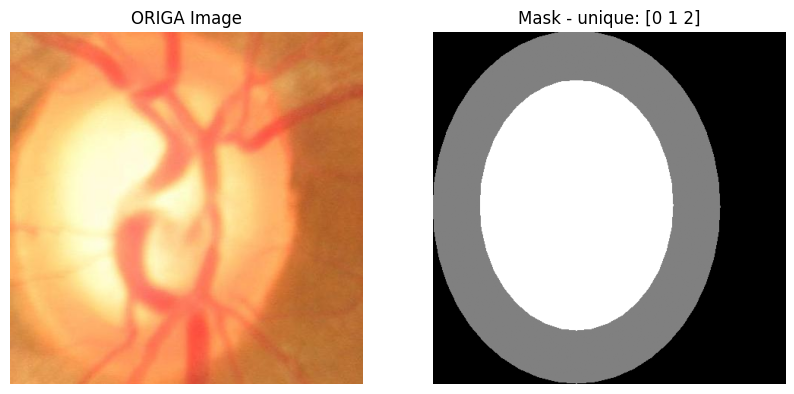

In [8]:
# Cell 6: Inspect ORIGA mask encoding -- confirm 0/1/2 before trusting CombinedLoss(num_classes=3)
ORIGA_IMG_DIR = "/content/data/ORIGA/Images_Cropped"
ORIGA_MASK_DIR = "/content/data/ORIGA/Masks_Cropped"

sample_files = sorted(os.listdir(ORIGA_MASK_DIR))[:8]
print("Sample mask files:", sample_files)
for f in sample_files:
    m = cv2.imread(os.path.join(ORIGA_MASK_DIR, f), cv2.IMREAD_UNCHANGED)
    print(f, "-> shape:", m.shape, "dtype:", m.dtype, "unique values:", np.unique(m))

img_files = sorted(os.listdir(ORIGA_IMG_DIR))
sample_img = cv2.imread(os.path.join(ORIGA_IMG_DIR, img_files[0]))
sample_mask = cv2.imread(os.path.join(ORIGA_MASK_DIR, sample_files[0]), cv2.IMREAD_UNCHANGED)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("ORIGA Image"); ax[0].axis('off')
ax[1].imshow(sample_mask, cmap='gray'); ax[1].set_title(f"Mask - unique: {np.unique(sample_mask)}"); ax[1].axis('off')
plt.show()

In [9]:
# Cell 7: Dataset class -- same as REFUGEDataset, but accepts a pre-built `filenames` list
# instead of always scanning the whole directory, since G1020 needs a manual train/val/test split.
class GlaucomaDataset(Dataset):
    def __init__(self, img_dir, mask_dir, filenames=None, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        if filenames is not None:
            self.filenames = filenames
        else:
            self.filenames = []
            for f in sorted(os.listdir(img_dir)):
                base = os.path.splitext(f)[0]
                mask_path = os.path.join(mask_dir, base + ".png")
                if os.path.exists(mask_path):
                    self.filenames.append((f, base + ".png"))
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name, mask_name = self.filenames[idx]
        image = cv2.imread(os.path.join(self.img_dir, img_name))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_UNCHANGED)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']
        return image, mask.long()

In [12]:
# Cell 8: Transforms and DataLoaders
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 256  # every image gets resized here regardless of its raw cropped size (Cell 6 note)
# Cell 8: Transforms and DataLoaders for ORIGA
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

USE_OFFICIAL_SPLIT = True   # True = OrigaList.csv 'Set' column (A=train, B=test) -- matches published benchmarks
                            # False = random 70/15/15, same style as our G1020 notebook

import pandas as pd
from sklearn.model_selection import train_test_split

list_df = pd.read_csv("/content/data/ORIGA/OrigaList.csv")
list_df["base_id"] = list_df["Filename"].apply(lambda x: os.path.splitext(x)[0])

all_pairs = []
for f in sorted(os.listdir(ORIGA_IMG_DIR)):
    base = os.path.splitext(f)[0]
    mask_path = os.path.join(ORIGA_MASK_DIR, base + ".png")
    if os.path.exists(mask_path):
        all_pairs.append((f, base + ".png", base))

print("Total ORIGA image/mask pairs found:", len(all_pairs))

if USE_OFFICIAL_SPLIT:
    set_lookup = dict(zip(list_df["base_id"], list_df["Set"]))
    print("Unique Set values found in CSV:", list_df["Set"].unique())
    train_full = [(img, msk) for img, msk, base in all_pairs if set_lookup.get(base) == 'A']
    test_pairs  = [(img, msk) for img, msk, base in all_pairs if set_lookup.get(base) == 'B']
    train_pairs, val_pairs = train_test_split(train_full, test_size=0.15, random_state=SEED)
    print(f"[Official ORIGA split] Train: {len(train_pairs)}  Val: {len(val_pairs)}  Test: {len(test_pairs)}")
else:
    pairs_only = [(img, msk) for img, msk, base in all_pairs]
    train_pairs, temp_pairs = train_test_split(pairs_only, test_size=0.30, random_state=SEED)
    val_pairs, test_pairs   = train_test_split(temp_pairs, test_size=0.50, random_state=SEED)
    print(f"[Random 70/15/15 split] Train: {len(train_pairs)}  Val: {len(val_pairs)}  Test: {len(test_pairs)}")

train_ds = GlaucomaDataset(ORIGA_IMG_DIR, ORIGA_MASK_DIR, filenames=train_pairs, transform=train_transform)
val_ds   = GlaucomaDataset(ORIGA_IMG_DIR, ORIGA_MASK_DIR, filenames=val_pairs,   transform=val_transform)
test_ds  = GlaucomaDataset(ORIGA_IMG_DIR, ORIGA_MASK_DIR, filenames=test_pairs,  transform=val_transform)

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

imgs, masks = next(iter(train_loader))
print("Batch image shape:", imgs.shape, "Batch mask shape:", masks.shape)
print("Mask unique values in batch:", torch.unique(masks))

Total ORIGA image/mask pairs found: 650
Unique Set values found in CSV: ['A' 'B']
[Official ORIGA split] Train: 276  Val: 49  Test: 325
Batch image shape: torch.Size([8, 3, 256, 256]) Batch mask shape: torch.Size([8, 256, 256])
Mask unique values in batch: tensor([0, 1, 2])


In [13]:
# Cell 9: KANLinear -- exact port of official kan.py (efficient-kan implementation)
class KANLinear(torch.nn.Module):
    def __init__(
        self, in_features, out_features, grid_size=5, spline_order=3,
        scale_noise=0.1, scale_base=1.0, scale_spline=1.0,
        enable_standalone_scale_spline=True, base_activation=torch.nn.SiLU,
        grid_eps=0.02, grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0])
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(torch.Tensor(out_features, in_features))

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 1 / 2)
                * self.scale_noise / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(self.grid.T[self.spline_order : -self.spline_order], noise)
            )
            if self.enable_standalone_scale_spline:
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        assert x.dim() == 2 and x.size(1) == self.in_features
        grid: torch.Tensor = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)]) / (grid[:, k:-1] - grid[:, : -(k + 1)]) * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x) / (grid[:, k + 1 :] - grid[:, 1:(-k)]) * bases[:, :, 1:]
            )
        assert bases.size() == (x.size(0), self.in_features, self.grid_size + self.spline_order)
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        result = solution.permute(2, 0, 1)
        assert result.size() == (self.out_features, self.in_features, self.grid_size + self.spline_order)
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1) if self.enable_standalone_scale_spline else 1.0
        )

    def forward(self, x: torch.Tensor):
        orig_shape = x.shape
        x = x.reshape(-1, self.in_features)
        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        out = base_output + spline_output
        return out.reshape(*orig_shape[:-1], self.out_features)


In [14]:
# Sanity test of KANLinear
test_layer = KANLinear(in_features=16, out_features=32).to(DEVICE)
test_input = torch.randn(4, 10, 16).to(DEVICE)
test_output = test_layer(test_input)
print("KANLinear test output shape:", test_output.shape)  # expect (4, 10, 32)


KANLinear test output shape: torch.Size([4, 10, 32])


In [15]:
# Cell 10: KANLayer + KANBlock -- exact port of archs.py
# 3 KANLinear sublayers per layer (fc1, fc2, fc3), each followed by DW_bn_relu
# (depthwise conv + BatchNorm + ReLU), all wrapped in ONE residual connection in KANBlock.
from timm.models.layers import DropPath, to_2tuple, trunc_normal_

class DWConv(nn.Module):
    def __init__(self, dim=768):
        super(DWConv, self).__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class DW_bn_relu(nn.Module):
    def __init__(self, dim=768):
        super(DW_bn_relu, self).__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.relu = nn.ReLU()

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class KANLayer(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0., no_kan=False):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.dim = in_features

        grid_size, spline_order = 5, 3
        scale_noise, scale_base, scale_spline = 0.1, 1.0, 1.0
        base_activation, grid_eps, grid_range = torch.nn.SiLU, 0.02, [-1, 1]

        if not no_kan:
            self.fc1 = KANLinear(in_features, hidden_features, grid_size=grid_size, spline_order=spline_order,
                                  scale_noise=scale_noise, scale_base=scale_base, scale_spline=scale_spline,
                                  base_activation=base_activation, grid_eps=grid_eps, grid_range=grid_range)
            self.fc2 = KANLinear(hidden_features, out_features, grid_size=grid_size, spline_order=spline_order,
                                  scale_noise=scale_noise, scale_base=scale_base, scale_spline=scale_spline,
                                  base_activation=base_activation, grid_eps=grid_eps, grid_range=grid_range)
            self.fc3 = KANLinear(hidden_features, out_features, grid_size=grid_size, spline_order=spline_order,
                                  scale_noise=scale_noise, scale_base=scale_base, scale_spline=scale_spline,
                                  base_activation=base_activation, grid_eps=grid_eps, grid_range=grid_range)
        else:
            self.fc1 = nn.Linear(in_features, hidden_features)
            self.fc2 = nn.Linear(hidden_features, out_features)
            self.fc3 = nn.Linear(hidden_features, out_features)

        self.dwconv_1 = DW_bn_relu(hidden_features)
        self.dwconv_2 = DW_bn_relu(hidden_features)
        self.dwconv_3 = DW_bn_relu(hidden_features)

        self.drop = nn.Dropout(drop)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = self.fc1(x.reshape(B*N, C))
        x = x.reshape(B, N, C).contiguous()
        x = self.dwconv_1(x, H, W)
        x = self.fc2(x.reshape(B*N, C))
        x = x.reshape(B, N, C).contiguous()
        x = self.dwconv_2(x, H, W)
        x = self.fc3(x.reshape(B*N, C))
        x = x.reshape(B, N, C).contiguous()
        x = self.dwconv_3(x, H, W)
        return x


class KANBlock(nn.Module):
    def __init__(self, dim, drop=0., drop_path=0., act_layer=nn.GELU, norm_layer=nn.LayerNorm, no_kan=False):
        super().__init__()
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim)
        self.layer = KANLayer(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop, no_kan=no_kan)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        x = x + self.drop_path(self.layer(self.norm2(x), H, W))
        return x


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [16]:
# Sanity test of KANBlock
test_block = KANBlock(dim=32).to(DEVICE)
test_tokens = torch.randn(2, 64, 32).to(DEVICE)
out = test_block(test_tokens, H=8, W=8)
print("KANBlock output shape:", out.shape)  # expect (2, 64, 32)


KANBlock output shape: torch.Size([2, 64, 32])


In [17]:
# Cell 11: PatchEmbed + ConvLayer + D_ConvLayer -- exact port of archs.py
class PatchEmbed(nn.Module):
    """ Image to Patch Embedding """
    def __init__(self, img_size=224, patch_size=7, stride=4, in_chans=3, embed_dim=768):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)

        self.img_size = img_size
        self.patch_size = patch_size
        self.H, self.W = img_size[0] // patch_size[0], img_size[1] // patch_size[1]
        self.num_patches = self.H * self.W
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride,
                              padding=(patch_size[0] // 2, patch_size[1] // 2))
        self.norm = nn.LayerNorm(embed_dim)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x, H, W


class ConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(ConvLayer, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, input):
        return self.conv(input)


class D_ConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(D_ConvLayer, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, input):
        return self.conv(input)


In [18]:
# Cell 12: Full U-KAN model -- exact port of official archs.py
class UKAN(nn.Module):
    def __init__(self, num_classes, input_channels=3, deep_supervision=False, img_size=224, patch_size=16,
                 in_chans=3, embed_dims=[256, 320, 512], no_kan=False,
                 drop_rate=0., drop_path_rate=0., norm_layer=nn.LayerNorm, depths=[1, 1, 1], **kwargs):
        super().__init__()

        kan_input_dim = embed_dims[0]

        self.encoder1 = ConvLayer(input_channels, kan_input_dim // 8)
        self.encoder2 = ConvLayer(kan_input_dim // 8, kan_input_dim // 4)
        self.encoder3 = ConvLayer(kan_input_dim // 4, kan_input_dim)

        self.norm3 = norm_layer(embed_dims[1])
        self.norm4 = norm_layer(embed_dims[2])

        self.dnorm3 = norm_layer(embed_dims[1])
        self.dnorm4 = norm_layer(embed_dims[0])

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]

        self.block1 = nn.ModuleList([KANBlock(
            dim=embed_dims[1], drop=drop_rate, drop_path=dpr[0], norm_layer=norm_layer)])

        self.block2 = nn.ModuleList([KANBlock(
            dim=embed_dims[2], drop=drop_rate, drop_path=dpr[1], norm_layer=norm_layer)])

        self.dblock1 = nn.ModuleList([KANBlock(
            dim=embed_dims[1], drop=drop_rate, drop_path=dpr[0], norm_layer=norm_layer)])

        self.dblock2 = nn.ModuleList([KANBlock(
            dim=embed_dims[0], drop=drop_rate, drop_path=dpr[1], norm_layer=norm_layer)])

        self.patch_embed3 = PatchEmbed(img_size=img_size // 4, patch_size=3, stride=2,
                                        in_chans=embed_dims[0], embed_dim=embed_dims[1])
        self.patch_embed4 = PatchEmbed(img_size=img_size // 8, patch_size=3, stride=2,
                                        in_chans=embed_dims[1], embed_dim=embed_dims[2])

        self.decoder1 = D_ConvLayer(embed_dims[2], embed_dims[1])
        self.decoder2 = D_ConvLayer(embed_dims[1], embed_dims[0])
        self.decoder3 = D_ConvLayer(embed_dims[0], embed_dims[0] // 4)
        self.decoder4 = D_ConvLayer(embed_dims[0] // 4, embed_dims[0] // 8)
        self.decoder5 = D_ConvLayer(embed_dims[0] // 8, embed_dims[0] // 8)

        self.final = nn.Conv2d(embed_dims[0] // 8, num_classes, kernel_size=1)
        self.soft = nn.Softmax(dim=1)

    def forward(self, x):
        B = x.shape[0]

        out = F.relu(F.max_pool2d(self.encoder1(x), 2, 2))
        t1 = out
        out = F.relu(F.max_pool2d(self.encoder2(out), 2, 2))
        t2 = out
        out = F.relu(F.max_pool2d(self.encoder3(out), 2, 2))
        t3 = out

        out, H, W = self.patch_embed3(out)
        for blk in self.block1:
            out = blk(out, H, W)
        out = self.norm3(out)
        out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        t4 = out

        out, H, W = self.patch_embed4(out)
        for blk in self.block2:
            out = blk(out, H, W)
        out = self.norm4(out)
        out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

        out = F.relu(F.interpolate(self.decoder1(out), scale_factor=(2, 2), mode='bilinear'))
        out = torch.add(out, t4)
        _, _, H, W = out.shape
        out = out.flatten(2).transpose(1, 2)
        for blk in self.dblock1:
            out = blk(out, H, W)

        out = self.dnorm3(out)
        out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        out = F.relu(F.interpolate(self.decoder2(out), scale_factor=(2, 2), mode='bilinear'))
        out = torch.add(out, t3)
        _, _, H, W = out.shape
        out = out.flatten(2).transpose(1, 2)
        for blk in self.dblock2:
            out = blk(out, H, W)

        out = self.dnorm4(out)
        out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

        out = F.relu(F.interpolate(self.decoder3(out), scale_factor=(2, 2), mode='bilinear'))
        out = torch.add(out, t2)
        out = F.relu(F.interpolate(self.decoder4(out), scale_factor=(2, 2), mode='bilinear'))
        out = torch.add(out, t1)
        out = F.relu(F.interpolate(self.decoder5(out), scale_factor=(2, 2), mode='bilinear'))

        return self.final(out)


In [19]:
# Cell 13: Full end-to-end sanity test, and a check of the optimizer's param-group split
model = UKAN(num_classes=3, input_channels=3, img_size=IMG_SIZE, embed_dims=[256, 320, 512], no_kan=False).to(DEVICE)
dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out = model(dummy)
print("Output shape:", out.shape)   # expect (4, 3, 256, 256)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Param-group sanity check: confirms which params get lr=1e-2 (KAN) vs lr=1e-4 (backbone)
# in Cell 15's optimizer, BEFORE a full run. If kan_count is 0, the name-matching missed something.
kan_count = sum(p.numel() for n, p in model.named_parameters() if 'layer' in n.lower() and 'fc' in n.lower())
other_count = sum(p.numel() for n, p in model.named_parameters() if not ('layer' in n.lower() and 'fc' in n.lower()))
print(f"KAN-layer params (will use lr=1e-2): {kan_count:,}")
print(f"Backbone params  (will use lr=1e-4): {other_count:,}")


Output shape: torch.Size([4, 3, 256, 256])
Trainable parameters: 25,359,331
KAN-layer params (will use lr=1e-2): 15,974,400
Backbone params  (will use lr=1e-4): 9,384,931


In [20]:
# Cell 14: Loss function and full metrics suite
class DiceLoss(nn.Module):
    """Soft Dice loss, differentiable -- used only inside CombinedLoss for backprop."""
    def __init__(self, num_classes=3, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        union = torch.sum(probs + targets_onehot, dims)
        dice_per_class = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_per_class.mean()


class CombinedLoss(nn.Module):
    """0.5 * CrossEntropy + 0.5 * Dice -- the loss actually optimized during training."""
    def __init__(self, num_classes=3):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)

    def forward(self, logits, targets):
        return 0.5 * self.ce(logits, targets) + 0.5 * self.dice(logits, targets)


@torch.no_grad()
def confusion_counts_per_class(logits, targets, num_classes=3):
    """
    Returns raw TP/FP/FN/TN pixel counts per class for ONE batch.
    These get accumulated across a whole epoch/split before computing any ratio --
    NEVER average precision/recall/dice/iou directly across batches, since batches
    don't have equal pixel counts per class and that biases the result.
    """
    preds = torch.argmax(logits, dim=1)
    counts = torch.zeros(num_classes, 4)  # columns: TP, FP, FN, TN
    for c in range(num_classes):
        pred_c = (preds == c)
        target_c = (targets == c)
        tp = (pred_c & target_c).sum().item()
        fp = (pred_c & ~target_c).sum().item()
        fn = (~pred_c & target_c).sum().item()
        tn = (~pred_c & ~target_c).sum().item()
        counts[c] = torch.tensor([tp, fp, fn, tn])
    return counts


def metrics_from_counts(counts, smooth=1e-6):
    """
    counts: (num_classes, 4) tensor of accumulated [TP, FP, FN, TN] summed over an entire split.
    Returns per-class precision, recall, f1 (== dice), iou, one-vs-rest accuracy.
    NOTE: F1 and Dice are mathematically IDENTICAL (2*TP / (2*TP+FP+FN)) -- not two different
    numbers, the same formula under two names. Both are reported since both names were requested.
    NOTE: per-class 'accuracy' is one-vs-rest and will look artificially high for the dominant
    class (background) -- use overall_accuracy (computed in run_epoch) for the honest number.
    """
    num_classes = counts.shape[0]
    metrics = {"precision": [], "recall": [], "f1": [], "dice": [], "iou": [], "accuracy": []}
    for c in range(num_classes):
        tp, fp, fn, tn = counts[c]
        precision = (tp + smooth) / (tp + fp + smooth)
        recall    = (tp + smooth) / (tp + fn + smooth)
        f1_dice   = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
        iou       = (tp + smooth) / (tp + fp + fn + smooth)
        acc       = (tp + tn + smooth) / (tp + tn + fp + fn + smooth)
        metrics["precision"].append(precision.item())
        metrics["recall"].append(recall.item())
        metrics["f1"].append(f1_dice.item())
        metrics["dice"].append(f1_dice.item())
        metrics["iou"].append(iou.item())
        metrics["accuracy"].append(acc.item())
    return metrics


In [21]:
# Cell 15: Training loop with full metrics (identical logic to REFUGE/G1020 notebooks --
# only the checkpoint filename changes, so ORIGA's best model doesn't overwrite the others)
def run_epoch(model, loader, criterion, device, optimizer=None, num_classes=3):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    total_counts = torch.zeros(num_classes, 4)
    overall_correct, overall_total = 0, 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            if is_train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            if is_train:
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * images.size(0)

            with torch.no_grad():
                total_counts += confusion_counts_per_class(outputs.detach(), masks, num_classes)
                preds = torch.argmax(outputs.detach(), dim=1)
                overall_correct += (preds == masks).sum().item()
                overall_total += masks.numel()

    avg_loss = running_loss / len(loader.dataset)
    metrics = metrics_from_counts(total_counts)
    metrics["overall_accuracy"] = overall_correct / overall_total
    metrics["mean_dice_dc"] = (metrics["dice"][1] + metrics["dice"][2]) / 2
    metrics["mean_iou_dc"]  = (metrics["iou"][1]  + metrics["iou"][2])  / 2
    return avg_loss, metrics


def train_model(model, train_loader, val_loader, num_epochs=100, patience=15,
                 lr=1e-4, kan_lr=1e-2, weight_decay=1e-4, kan_weight_decay=1e-4, min_lr=1e-5):
    param_groups = []
    for name, param in model.named_parameters():
        if 'layer' in name.lower() and 'fc' in name.lower():
            param_groups.append({'params': param, 'lr': kan_lr, 'weight_decay': kan_weight_decay})
        else:
            param_groups.append({'params': param, 'lr': lr, 'weight_decay': weight_decay})

    optimizer = torch.optim.Adam(param_groups)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=min_lr)
    criterion = CombinedLoss(num_classes=3)

    class_names = ["bg", "disc", "cup"]
    metric_names = ["precision", "recall", "f1", "dice", "iou", "accuracy"]

    history = {"train_loss": [], "val_loss": [],
               "train_overall_accuracy": [], "val_overall_accuracy": [],
               "train_mean_dice_dc": [], "val_mean_dice_dc": [],
               "train_mean_iou_dc": [], "val_mean_iou_dc": []}
    for m in metric_names:
        for split in ["train", "val"]:
            for cn in class_names:
                history[f"{split}_{m}_{cn}"] = []

    best_mean_dice = 0.0
    epochs_no_improve = 0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_metrics = run_epoch(model, train_loader, criterion, DEVICE, optimizer=optimizer)
        val_loss, val_metrics = run_epoch(model, val_loader, criterion, DEVICE, optimizer=None)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_overall_accuracy"].append(train_metrics["overall_accuracy"])
        history["val_overall_accuracy"].append(val_metrics["overall_accuracy"])
        history["train_mean_dice_dc"].append(train_metrics["mean_dice_dc"])
        history["val_mean_dice_dc"].append(val_metrics["mean_dice_dc"])
        history["train_mean_iou_dc"].append(train_metrics["mean_iou_dc"])
        history["val_mean_iou_dc"].append(val_metrics["mean_iou_dc"])
        for m in metric_names:
            for i, cn in enumerate(class_names):
                history[f"train_{m}_{cn}"].append(train_metrics[m][i])
                history[f"val_{m}_{cn}"].append(val_metrics[m][i])

        lr_backbone = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"TrainLoss:{train_loss:.4f} ValLoss:{val_loss:.4f} | "
              f"TrainAcc:{train_metrics['overall_accuracy']:.4f} ValAcc:{val_metrics['overall_accuracy']:.4f} | "
              f"TrainMeanDice(D+C):{train_metrics['mean_dice_dc']:.4f} ValMeanDice(D+C):{val_metrics['mean_dice_dc']:.4f} | "
              f"TrainMeanIoU(D+C):{train_metrics['mean_iou_dc']:.4f} ValMeanIoU(D+C):{val_metrics['mean_iou_dc']:.4f} | "
              f"LR:{lr_backbone:.6f}")

        if val_metrics["mean_dice_dc"] > best_mean_dice:
            best_mean_dice = val_metrics["mean_dice_dc"]
            epochs_no_improve = 0
            torch.save(model.state_dict(), "/content/best_ukan_origa.pth")   # <- changed from _refuge/_g1020
            print(f"  -> New best model saved (Val Mean Dice D+C: {best_mean_dice:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch} (no improvement for {patience} epochs)")
                break

    return history

In [24]:
# Cell 16: Run training on ORIGA
model = UKAN(num_classes=3, input_channels=3, img_size=IMG_SIZE, embed_dims=[256, 320, 512], no_kan=False).to(DEVICE)
history = train_model(model, train_loader, val_loader, num_epochs=100, patience=25,
                       lr=1e-4, kan_lr=1e-2, weight_decay=1e-4, kan_weight_decay=1e-4, min_lr=1e-5)



Epoch   1/100 | TrainLoss:0.6267 ValLoss:0.5006 | TrainAcc:0.7127 ValAcc:0.8260 | TrainMeanDice(D+C):0.6935 ValMeanDice(D+C):0.7939 | TrainMeanIoU(D+C):0.5310 ValMeanIoU(D+C):0.6583 | LR:0.000100
  -> New best model saved (Val Mean Dice D+C: 0.7939)
Epoch   2/100 | TrainLoss:0.4702 ValLoss:0.4060 | TrainAcc:0.8432 ValAcc:0.8708 | TrainMeanDice(D+C):0.8291 ValMeanDice(D+C):0.8496 | TrainMeanIoU(D+C):0.7081 ValMeanIoU(D+C):0.7388 | LR:0.000100
  -> New best model saved (Val Mean Dice D+C: 0.8496)
Epoch   3/100 | TrainLoss:0.4253 ValLoss:0.4087 | TrainAcc:0.8558 ValAcc:0.8522 | TrainMeanDice(D+C):0.8380 ValMeanDice(D+C):0.8289 | TrainMeanIoU(D+C):0.7212 ValMeanIoU(D+C):0.7081 | LR:0.000100
Epoch   4/100 | TrainLoss:0.3904 ValLoss:0.3655 | TrainAcc:0.8663 ValAcc:0.8801 | TrainMeanDice(D+C):0.8482 ValMeanDice(D+C):0.8603 | TrainMeanIoU(D+C):0.7364 ValMeanIoU(D+C):0.7550 | LR:0.000100
  -> New best model saved (Val Mean Dice D+C: 0.8603)
Epoch   5/100 | TrainLoss:0.3708 ValLoss:0.3578 | Trai

In [25]:
# Cell 17: Test set evaluation on ORIGA
best_model = UKAN(num_classes=3, input_channels=3, img_size=IMG_SIZE, embed_dims=[256, 320, 512], no_kan=False).to(DEVICE)
best_model.load_state_dict(torch.load("/content/best_ukan_origa.pth"))
best_model.eval()

criterion = CombinedLoss(num_classes=3)
test_loss, test_metrics = run_epoch(best_model, test_loader, criterion, DEVICE, optimizer=None)

class_names = ["Background", "Disc", "Cup"]
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Overall Accuracy (true multi-class): {test_metrics['overall_accuracy']:.4f}")
print(f"Test Mean Dice (Disc+Cup): {test_metrics['mean_dice_dc']:.4f}")
print(f"Test Mean IoU  (Disc+Cup): {test_metrics['mean_iou_dc']:.4f}\n")
print(f"{'Class':<12}{'Precision':>10}{'Recall':>10}{'F1':>10}{'Dice':>10}{'IoU':>10}{'OvR-Acc':>10}")
for i, cn in enumerate(class_names):
    print(f"{cn:<12}{test_metrics['precision'][i]:>10.4f}{test_metrics['recall'][i]:>10.4f}"
          f"{test_metrics['f1'][i]:>10.4f}{test_metrics['dice'][i]:>10.4f}"
          f"{test_metrics['iou'][i]:>10.4f}{test_metrics['accuracy'][i]:>10.4f}")

Test Loss: 0.1848
Test Overall Accuracy (true multi-class): 0.9111
Test Mean Dice (Disc+Cup): 0.8882
Test Mean IoU  (Disc+Cup): 0.7992

Class        Precision    Recall        F1      Dice       IoU   OvR-Acc
Background      0.9630    0.9558    0.9594    0.9594    0.9219    0.9767
Disc            0.8839    0.9196    0.9014    0.9014    0.8205    0.9112
Cup             0.9019    0.8497    0.8750    0.8750    0.7779    0.9342


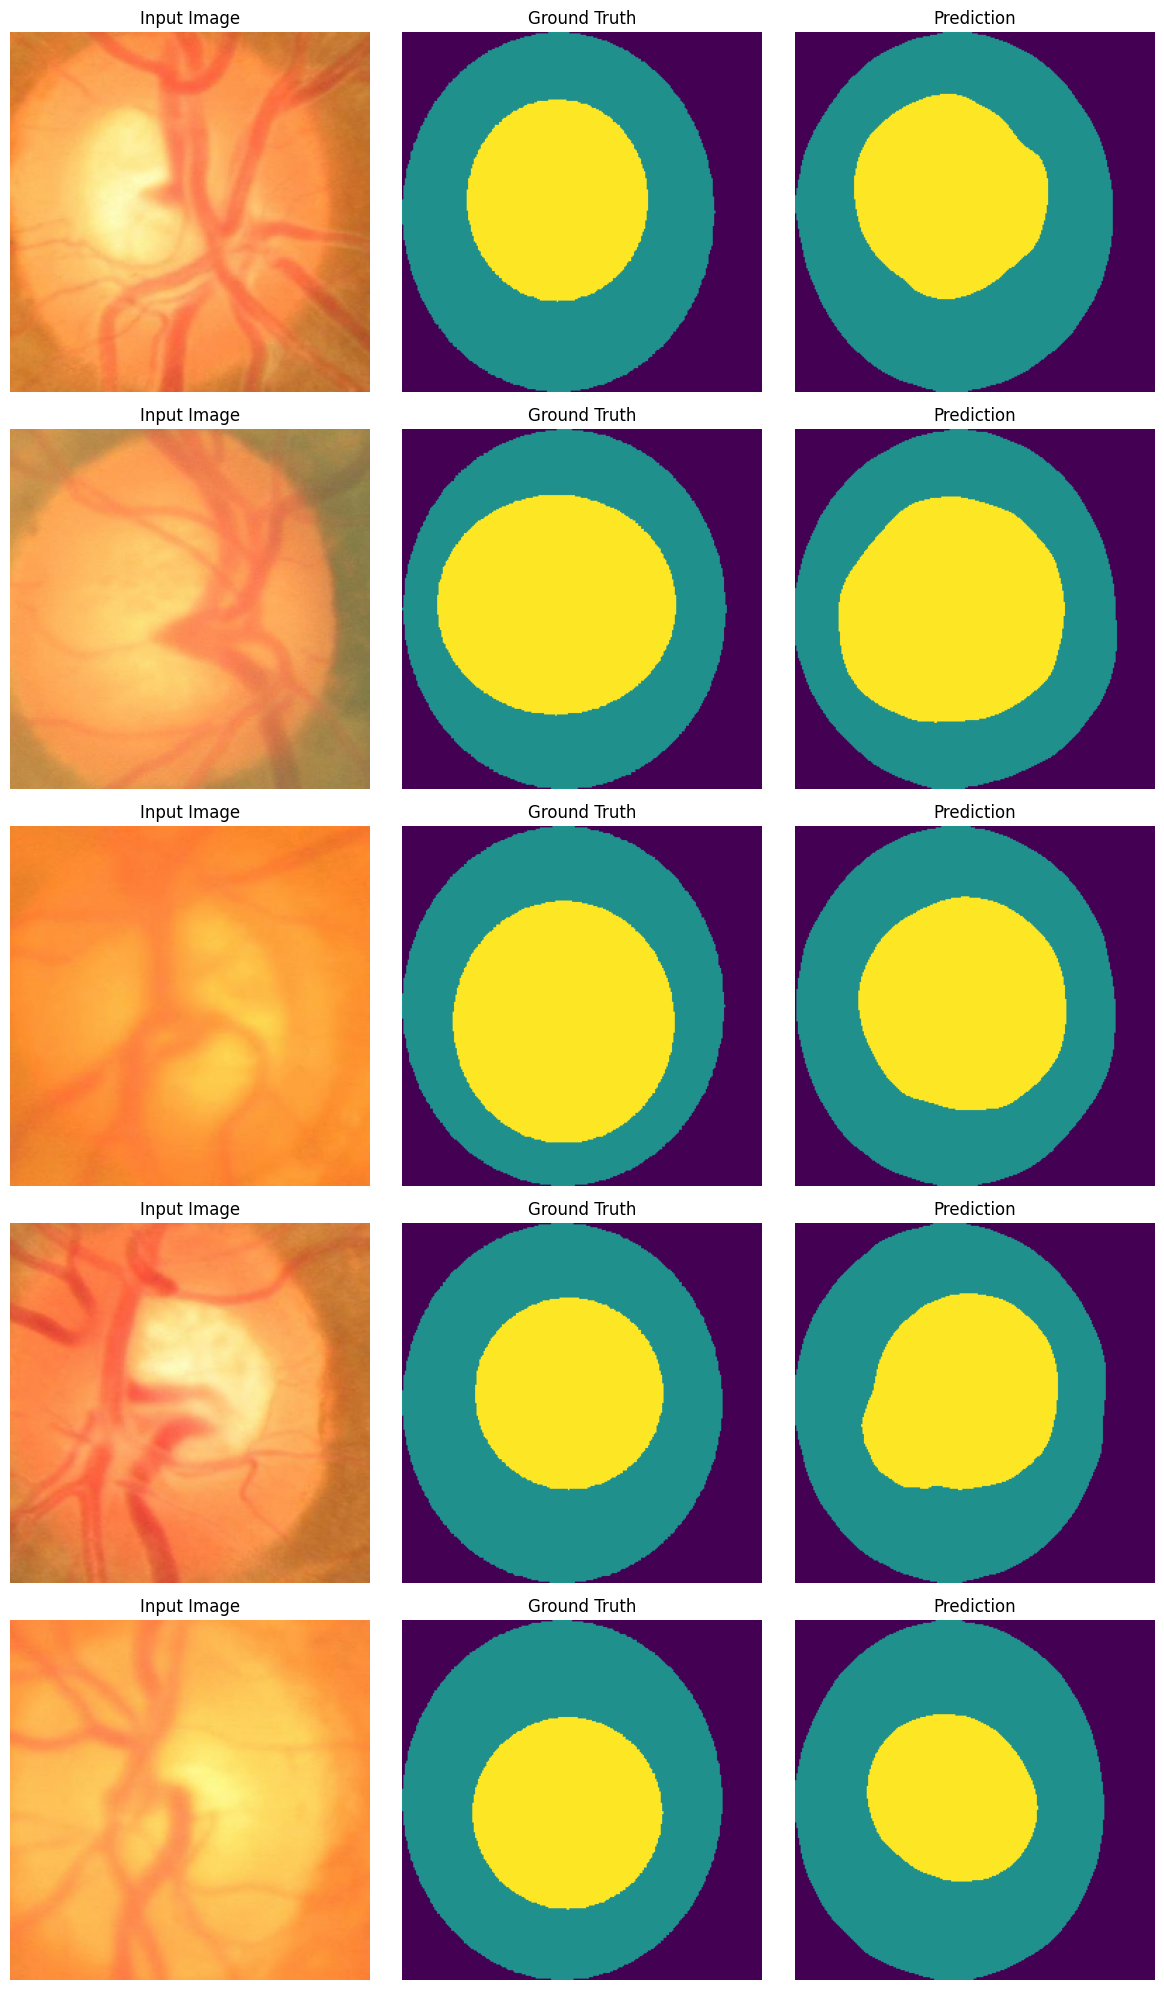

In [26]:
# Cell 18: Visualize predictions vs ground truth
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=5):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    indices = random.sample(range(len(dataset)), num_samples)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        pred = model(image.unsqueeze(0).to(device))
        pred_mask = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()
        img_np = (image.permute(1, 2, 0).cpu().numpy() * std + mean).clip(0, 1)

        axes[i, 0].imshow(img_np); axes[i, 0].set_title("Input Image"); axes[i, 0].axis('off')
        axes[i, 1].imshow(mask.cpu().numpy(), cmap='viridis', vmin=0, vmax=2); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
        axes[i, 2].imshow(pred_mask, cmap='viridis', vmin=0, vmax=2); axes[i, 2].set_title("Prediction"); axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('/content/predictions_sample.png', dpi=100)
    plt.show()

visualize_predictions(best_model, test_ds, DEVICE, num_samples=5)


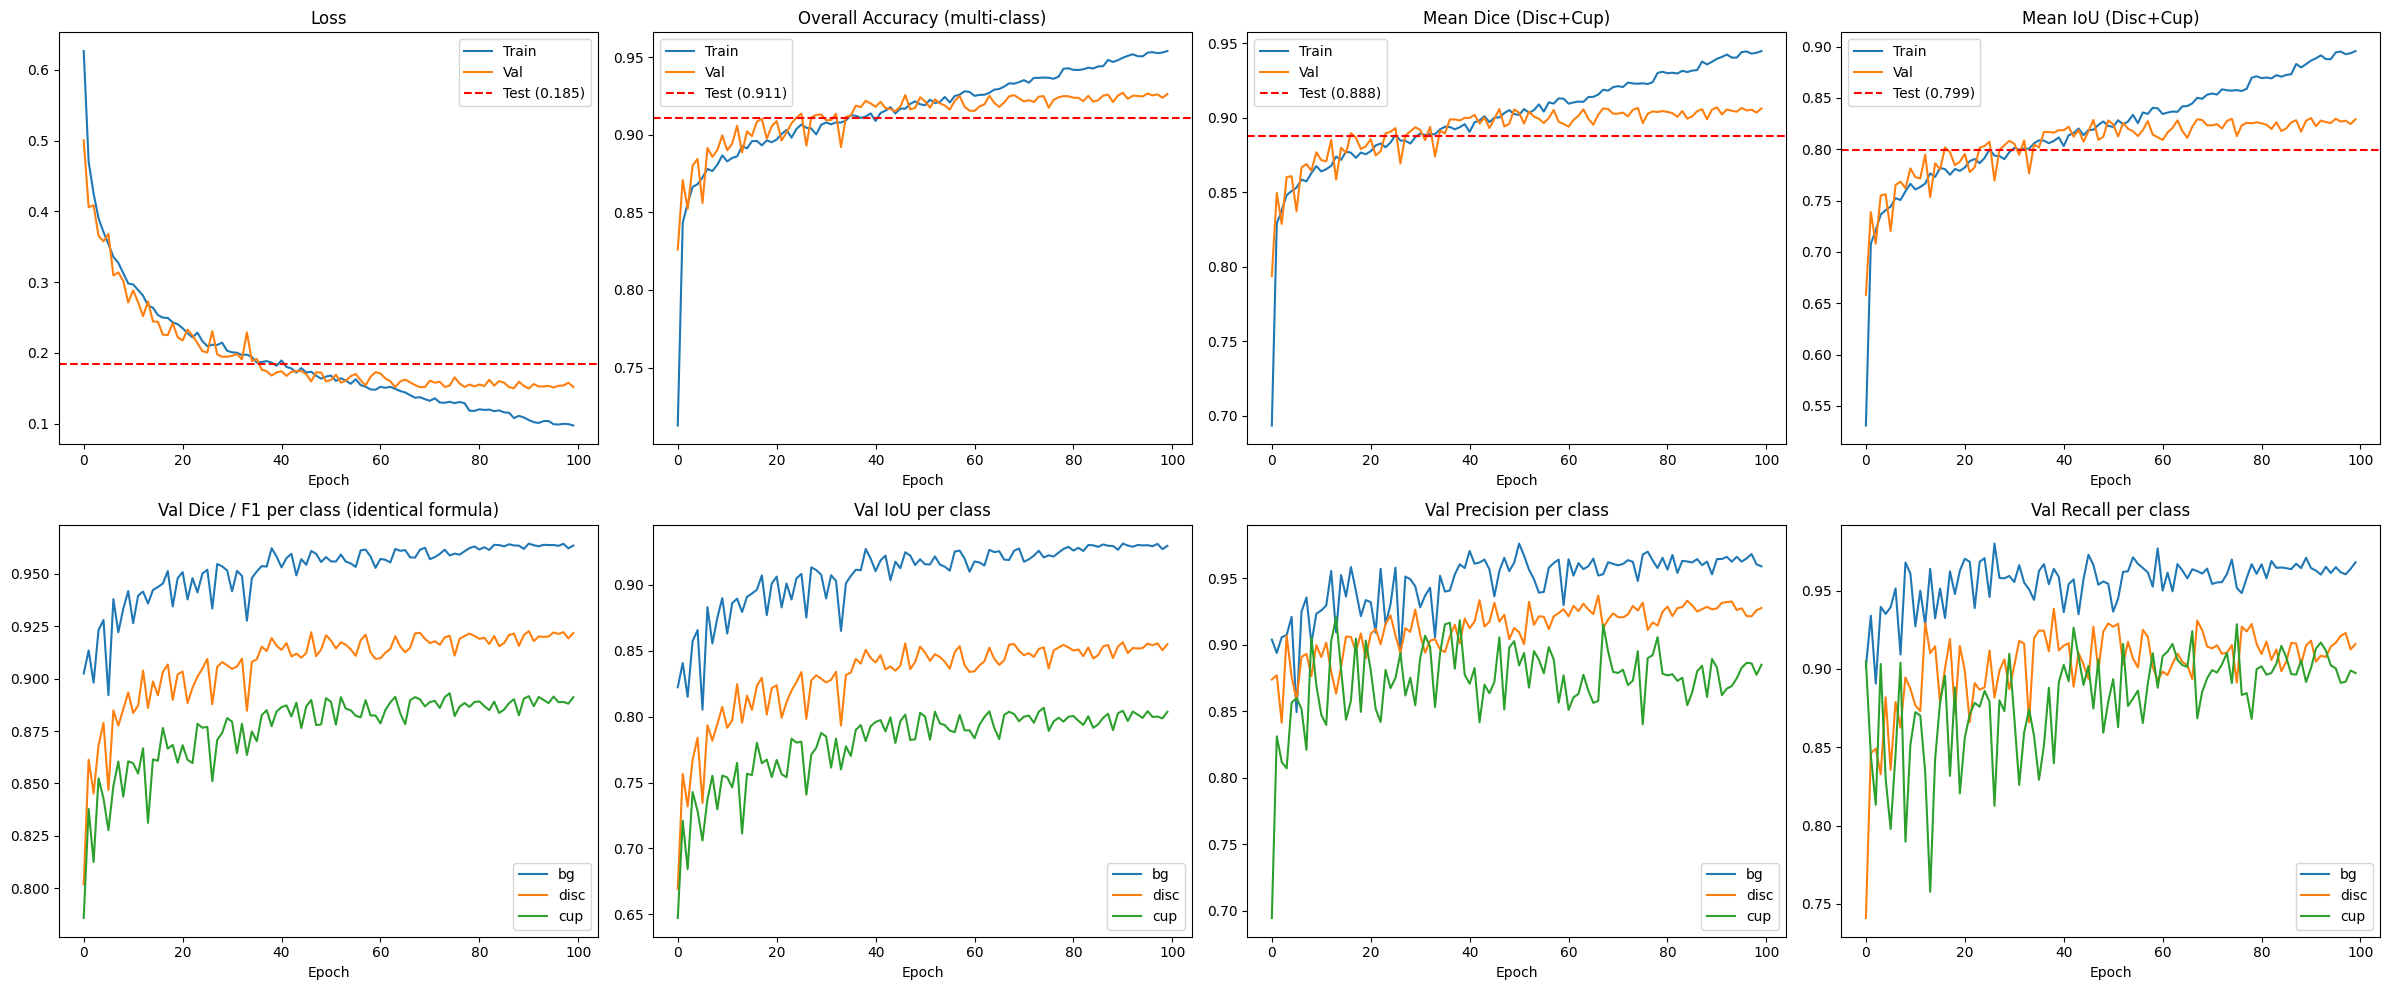

In [27]:
# Cell 19: Full training/validation/test plots
# NOTE: must run AFTER Cell 17 (uses test_loss / test_metrics for the dashed reference lines)
class_names = ["bg", "disc", "cup"]
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

axes[0,0].plot(history["train_loss"], label="Train")
axes[0,0].plot(history["val_loss"], label="Val")
axes[0,0].axhline(test_loss, color='red', linestyle='--', label=f"Test ({test_loss:.3f})")
axes[0,0].set_title("Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

axes[0,1].plot(history["train_overall_accuracy"], label="Train")
axes[0,1].plot(history["val_overall_accuracy"], label="Val")
axes[0,1].axhline(test_metrics["overall_accuracy"], color='red', linestyle='--',
                   label=f"Test ({test_metrics['overall_accuracy']:.3f})")
axes[0,1].set_title("Overall Accuracy (multi-class)"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend()

axes[0,2].plot(history["train_mean_dice_dc"], label="Train")
axes[0,2].plot(history["val_mean_dice_dc"], label="Val")
axes[0,2].axhline(test_metrics["mean_dice_dc"], color='red', linestyle='--',
                   label=f"Test ({test_metrics['mean_dice_dc']:.3f})")
axes[0,2].set_title("Mean Dice (Disc+Cup)"); axes[0,2].set_xlabel("Epoch"); axes[0,2].legend()

axes[0,3].plot(history["train_mean_iou_dc"], label="Train")
axes[0,3].plot(history["val_mean_iou_dc"], label="Val")
axes[0,3].axhline(test_metrics["mean_iou_dc"], color='red', linestyle='--',
                   label=f"Test ({test_metrics['mean_iou_dc']:.3f})")
axes[0,3].set_title("Mean IoU (Disc+Cup)"); axes[0,3].set_xlabel("Epoch"); axes[0,3].legend()

for cn in class_names:
    axes[1,0].plot(history[f"val_dice_{cn}"], label=cn)
axes[1,0].set_title("Val Dice / F1 per class (identical formula)"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend()

for cn in class_names:
    axes[1,1].plot(history[f"val_iou_{cn}"], label=cn)
axes[1,1].set_title("Val IoU per class"); axes[1,1].set_xlabel("Epoch"); axes[1,1].legend()

for cn in class_names:
    axes[1,2].plot(history[f"val_precision_{cn}"], label=cn)
axes[1,2].set_title("Val Precision per class"); axes[1,2].set_xlabel("Epoch"); axes[1,2].legend()

for cn in class_names:
    axes[1,3].plot(history[f"val_recall_{cn}"], label=cn)
axes[1,3].set_title("Val Recall per class"); axes[1,3].set_xlabel("Epoch"); axes[1,3].legend()

plt.tight_layout()
plt.savefig('/content/training_curves_full.png', dpi=100)
plt.show()
